<a href="https://colab.research.google.com/github/khoihole329-sudo/Minhkhoi/blob/main/L%C3%80M%20S%E1%BA%A0CH%20D%E1%BB%AE%20LI%E1%BB%86U%20C%C6%A0%20B%E1%BA%A2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

## 1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
#đầu tiên.

In [4]:
import pandas as pd
def load_data():
    data = pd.read_csv('/content/titanic_disaster.csv')
    return data
df = load_data()
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 2.Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

Age         177
Cabin       687
Embarked      2
dtype: int64


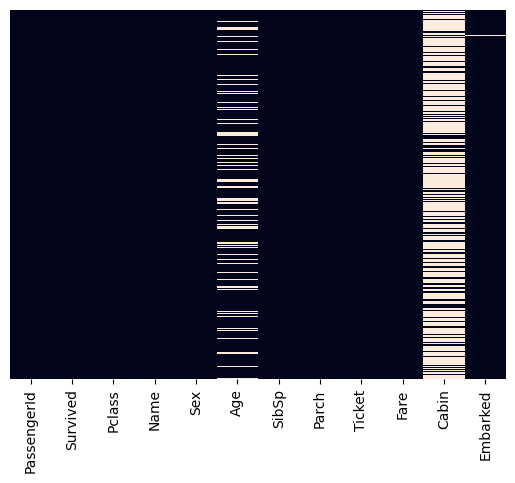

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
print(df[['Age','Cabin','Embarked']].isnull().sum())
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)
plt.show()

## 3.Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi tách cột xong thì xóa luôn cột Name

In [8]:
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)
df.drop('Name', axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


## 4.Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [9]:
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


## 5.Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa
##ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau
##a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân
##phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm
##hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.
##b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
##quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map

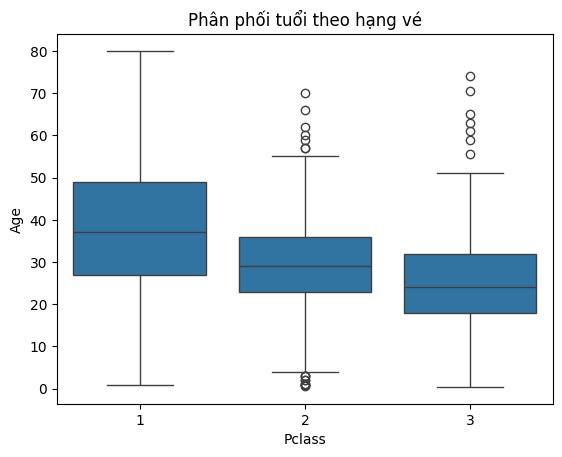

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64
0


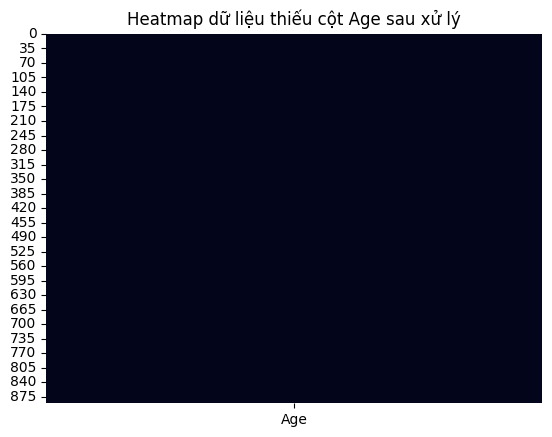

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Phân phối tuổi theo hạng vé')
plt.show()
print(df.groupby('Pclass')['Age'].mean())
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))
df[['Pclass', 'Age']].head(10)
print(df['Age'].isnull().sum())
sns.heatmap(df[['Age']].isnull(), cbar=False)
plt.title('Heatmap dữ liệu thiếu cột Age sau xử lý')
plt.show()

## 6.Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult và ( age > 60): Older

In [11]:
df['Agegroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, float('inf')],
    labels=['Kid', 'Teen', 'Adult', 'Older']
)

df[['Age', 'Agegroup']].head(10)

,Age,Agegroup
0,22.00000,Adult
1,38.00000,Adult
2,26.00000,Adult
3,35.00000,Adult
4,35.00000,Adult
5,25.14062,Adult
6,54.00000,Adult
7,2.00000,Kid
8,27.00000,Adult
9,14.00000,Teen


## 7.Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr,Mrs, Miss, Master ra khỏi “secondName”


In [13]:
df['namePrefix'] = df['secondName'].str.extract(r'\s*(\w+)\.')

df[['secondName', 'namePrefix']].head()

print(df['namePrefix'].value_counts())

namePrefix
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


## 8.Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [14]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'familySize']].head()
print(df['familySize'].value_counts().sort_index())

familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


## 9.Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [15]:
df['Alone'] = (df['familySize'] == 1).astype(int)

df[['familySize', 'Alone']].head()

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


## 10.Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu thì thay thế bằng “Unknown”

In [17]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].str[0]
df[['Cabin', 'typeCabin']].head()
print(df['typeCabin'].value_counts())

typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


## 11.Loại bỏ dữ liệu thừa đối với các hành khách xuất hiện trong cả 2 tập dữ liệu huấn luyện (train.csv) và đánh giá (test.csv). Ưu tiên giữ lại dữ liệu trong tập huấn luyện

In [35]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Tách dữ liệu thành train và test
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# Cố tình tạo dữ liệu trùng để mô phỏng
test_df = pd.concat([test_df, train_df.head(10)])

# Loại bỏ hành khách trùng, ưu tiên giữ train
test_df = test_df[~test_df['PassengerId'].isin(train_df['PassengerId'])]

# Gộp lại
df_clean = pd.concat([train_df, test_df], ignore_index=True)

print(df_clean.shape)

(891, 18)


## PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

##  12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính

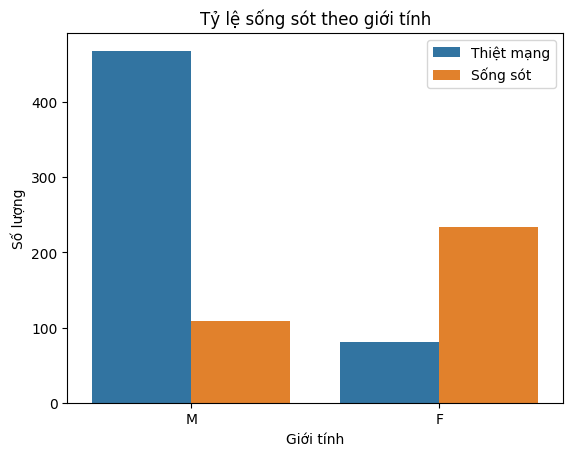

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Tỷ lệ sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(['Thiệt mạng', 'Sống sót'])
plt.show()

## 13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).


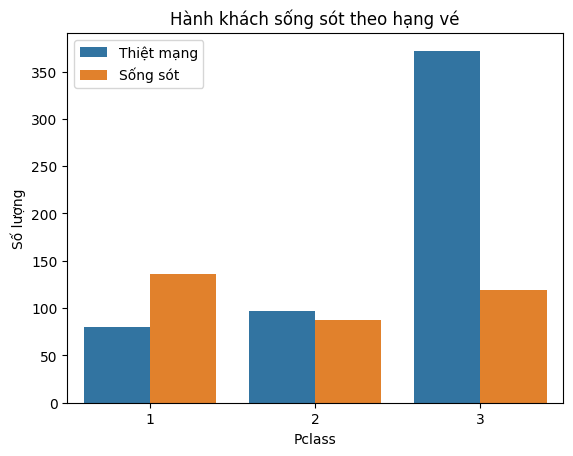

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Hành khách sống sót theo hạng vé')
plt.xlabel('Pclass')
plt.ylabel('Số lượng')
plt.legend(['Thiệt mạng', 'Sống sót'])
plt.show()

## 14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác

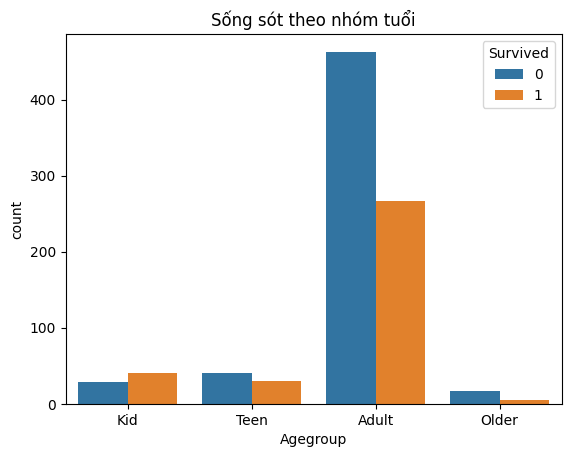

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Agegroup', hue='Survived')
plt.title('Sống sót theo nhóm tuổi')
plt.show()

## 15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

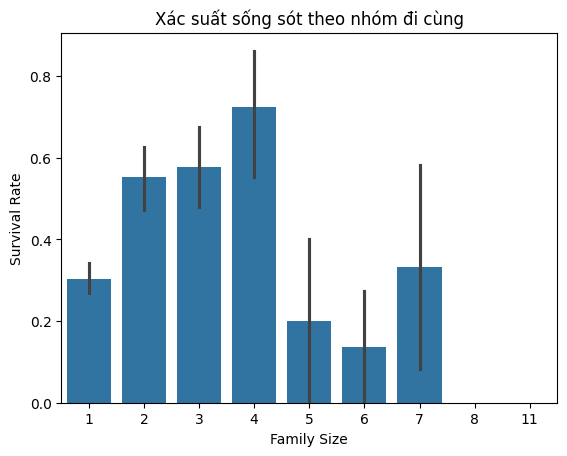

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='familySize', y='Survived')

plt.title('Xác suất sống sót theo nhóm đi cùng')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

## 16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé

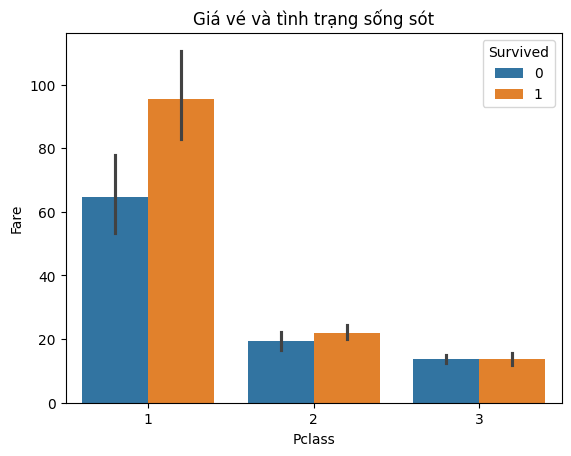

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='Pclass', y='Fare', hue='Survived')

plt.title('Giá vé và tình trạng sống sót')
plt.show()

## 17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến.

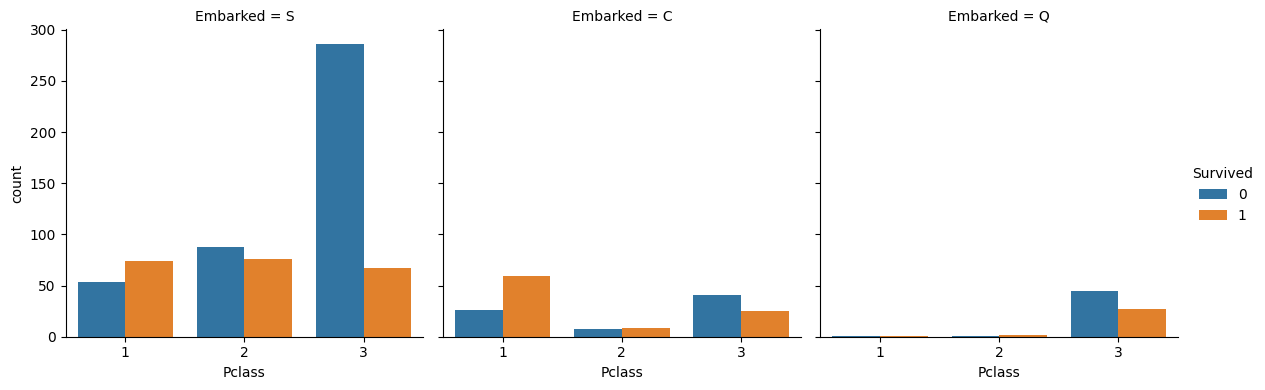

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.catplot(
    data=df,
    x='Pclass',
    hue='Survived',
    col='Embarked',
    kind='count',
    height=4,
    aspect=1
)
plt.show()